## Imports


In [4]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos RNA
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

# Lectura de RData
import pyreadr

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


In [5]:
# Carga del dataset
result = pyreadr.read_r('listings.RData')
df_raw = result['listings'].copy()
print(f'Dimensiones originales: {df_raw.shape}')

Dimensiones originales: (171748, 80)


In [6]:
# Limpieza de la columna precio
df_raw['price_clean'] = pd.to_numeric(
    df_raw['price'].str.replace('[\$,]', '', regex=True),
    errors='coerce'
)

# Eliminar filas sin precio o con precio <= 0
df = df_raw[df_raw['price_clean'].notna() & (df_raw['price_clean'] > 0)].copy()
print(f'Dimensiones tras limpiar precio: {df.shape}')
print(f'\nEstadísticas del precio:')
print(df['price_clean'].describe())

Dimensiones tras limpiar precio: (76246, 81)

Estadísticas del precio:
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price_clean, dtype: float64


In [7]:
# Selección de variables predictoras numéricas relevantes
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'availability_365',
    'calculated_host_listings_count'
]

# Convertir a numérico (bedrooms y beds pueden venir como object)
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Subset con features + precio
df_model = df[features + ['price_clean']].copy()
print(f'Dataset para modelado: {df_model.shape}')
print(f'Valores nulos por columna:')
print(df_model.isna().sum())

Dataset para modelado: (76246, 14)
Valores nulos por columna:
accommodates                          0
bedrooms                            121
beds                                 80
minimum_nights                        0
maximum_nights                        0
number_of_reviews                     0
review_scores_rating              13413
review_scores_cleanliness         13417
review_scores_location            13417
review_scores_value               13417
reviews_per_month                 13413
availability_365                      0
calculated_host_listings_count        0
price_clean                           0
dtype: int64


## Variable categorica


In [8]:
# Definir umbrales con percentiles 33 y 66
q33 = df_model['price_clean'].quantile(0.33)
q66 = df_model['price_clean'].quantile(0.66)

print(f'Percentil 33 (umbral Barata→Media): ${q33:.2f}')
print(f'Percentil 66 (umbral Media→Cara):   ${q66:.2f}')

def categorize_price(price):
    if price <= q33:
        return 'Barata'
    elif price <= q66:
        return 'Media'
    else:
        return 'Cara'

df_model['price_category'] = df_model['price_clean'].apply(categorize_price)

print(f'\nDistribución de categorías:')
print(df_model['price_category'].value_counts())
print(f'\nProporción:')
print(df_model['price_category'].value_counts(normalize=True).round(3))

Percentil 33 (umbral Barata→Media): $141.00
Percentil 66 (umbral Media→Cara):   $264.00

Distribución de categorías:
price_category
Cara      25897
Barata    25185
Media     25164
Name: count, dtype: int64

Proporción:
price_category
Cara      0.34
Barata    0.33
Media     0.33
Name: proportion, dtype: float64


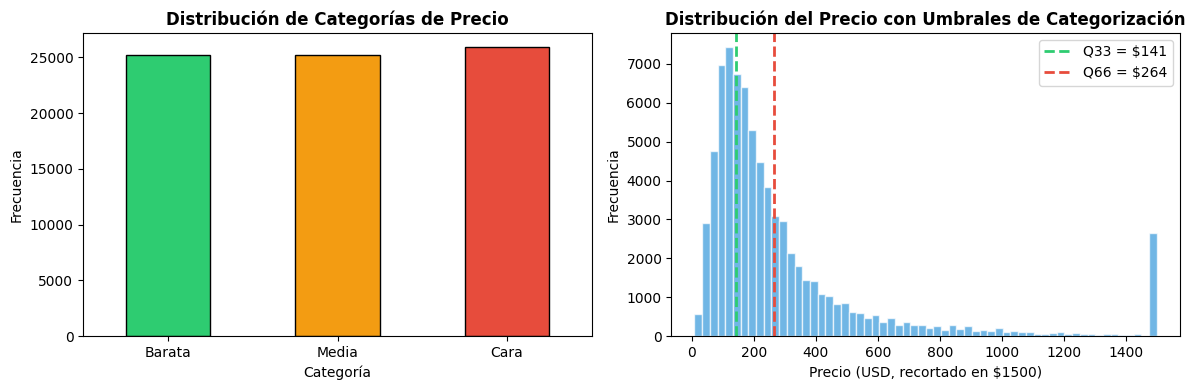

In [10]:
# Visualización de la distribución de categorías
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo de categorías
order = ['Barata', 'Media', 'Cara']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df_model['price_category'].value_counts()[order].plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black'
)
axes[0].set_title('Distribución de Categorías de Precio', fontweight='bold')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Histograma de precios con líneas de corte
precio_cap = df_model['price_clean'].clip(upper=1500)  # recortar outliers extremos para visualización
axes[1].hist(precio_cap, bins=60, color='#3498db', edgecolor='white', alpha=0.7)
axes[1].axvline(q33, color='#2ecc71', linestyle='--', linewidth=2, label=f'Q33 = ${q33:.0f}')
axes[1].axvline(q66, color='#e74c3c', linestyle='--', linewidth=2, label=f'Q66 = ${q66:.0f}')
axes[1].set_title('Distribución del Precio con Umbrales de Categorización', fontweight='bold')
axes[1].set_xlabel('Precio (USD, recortado en $1500)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribucion_categorias.png', dpi=150, bbox_inches='tight')
plt.show()


##Division de conjuntos 

In [11]:
# Variables predictoras X y variable respuesta y
X = df_model[features].copy()
y_cat = df_model['price_category'].copy()  # etiquetas de texto

# LabelEncoder: convierte a enteros para máxima compatibilidad con sklearn 1.8+
le = LabelEncoder()
y = pd.Series(le.fit_transform(y_cat), index=y_cat.index)
# Guardamos las clases originales para reportes y gráficos
clases_str = le.classes_.tolist()  # orden alfabético: ['Barata', 'Cara', 'Media']
print(f'Codificación: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]:,} registros')
print(f'Tamaño del conjunto de prueba:        {X_test.shape[0]:,} registros')
print(f'\nDistribución en entrenamiento (por código):')
print(pd.Series(le.inverse_transform(y_train), name='category').value_counts(normalize=True).round(3))
print(f'\nDistribución en prueba (por código):')
print(pd.Series(le.inverse_transform(y_test), name='category').value_counts(normalize=True).round(3))

Codificación: {'Barata': np.int64(0), 'Cara': np.int64(1), 'Media': np.int64(2)}
Tamaño del conjunto de entrenamiento: 60,996 registros
Tamaño del conjunto de prueba:        15,250 registros

Distribución en entrenamiento (por código):
category
Cara      0.34
Barata    0.33
Media     0.33
Name: proportion, dtype: float64

Distribución en prueba (por código):
category
Cara      0.34
Barata    0.33
Media     0.33
Name: proportion, dtype: float64


In [12]:
# Pipeline de preprocesamiento: imputación de medianas + normalización
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ajustar SOLO sobre entrenamiento para evitar data leakage
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f'Preprocesamiento completado')
print(f'X_train_prep shape: {X_train_prep.shape}')
print(f'X_test_prep shape:  {X_test_prep.shape}')

Preprocesamiento completado
X_train_prep shape: (60996, 13)
X_test_prep shape:  (15250, 13)


## Modelos para RNA 

In [13]:

# MODELO 1: Arquitectura profunda, activación ReLU


print('=' * 60)
print('MODELO 1 – Arquitectura profunda | Activación: ReLU')
print('Topología: Input → 128 → 64 → 32 → Output (3 clases)')
print('=' * 60)

mlp1 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),   # 3 capas ocultas
    activation='relu',                   # función de activación
    solver='adam',                       # optimizador
    max_iter=500,
    random_state=42,
    early_stopping=True,                 # detención temprana contra sobreajuste
    validation_fraction=0.1,
    n_iter_no_change=15,
    learning_rate_init=0.001,
    verbose=False
)

t0 = time.time()
mlp1.fit(X_train_prep, y_train)
tiempo_mlp1 = time.time() - t0

print(f'\n Entrenamiento completado en {tiempo_mlp1:.2f} segundos')
print(f'   Épocas ejecutadas: {mlp1.n_iter_}')
print(f'   Mejor pérdida de validacion: {mlp1.best_validation_score_:.4f}')

MODELO 1 – Arquitectura profunda | Activación: ReLU
Topología: Input → 128 → 64 → 32 → Output (3 clases)

 Entrenamiento completado en 5.13 segundos
   Épocas ejecutadas: 41
   Mejor pérdida de validacion: 0.6695


In [15]:
# MODELO 2: Arquitectura ancha, activación tanh

print('=' * 60)
print('MODELO 2 – Arquitectura ancha | Activación: tanh')
print('Topología: Input → 256 → 64 → Output (3 clases)')
print('=' * 60)

mlp2 = MLPClassifier(
    hidden_layer_sizes=(256, 64),        # 2 capas ocultas más anchas
    activation='tanh',                   # función de activación
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    learning_rate_init=0.001,
    verbose=False
)

t0 = time.time()
mlp2.fit(X_train_prep, y_train)
tiempo_mlp2 = time.time() - t0

print(f'\n Entrenamiento completado en {tiempo_mlp2:.2f} segundos')
print(f'   Épocas ejecutadas: {mlp2.n_iter_}')
print(f'   Mejor pérdida de validación: {mlp2.best_validation_score_:.4f}')

MODELO 2 – Arquitectura ancha | Activación: tanh
Topología: Input → 256 → 64 → Output (3 clases)

 Entrenamiento completado en 5.67 segundos
   Épocas ejecutadas: 40
   Mejor pérdida de validación: 0.6600


##Prediccion 

In [16]:
# Predicciones sobre el conjunto de PRUEBA
pred_mlp1 = mlp1.predict(X_test_prep)
pred_mlp2 = mlp2.predict(X_test_prep)

# Predicciones sobre el conjunto de ENTRENAMIENTO (para análisis de sobreajuste)
pred_train_mlp1 = mlp1.predict(X_train_prep)
pred_train_mlp2 = mlp2.predict(X_train_prep)

print('Predicciones generadas para ambos modelos')
print(f'\nMuestra de predicciones Modelo 1 (primeros 10):')
print(pred_mlp1[:10])
print(f'\nMuestra de predicciones Modelo 2 (primeros 10):')
print(pred_mlp2[:10])

Predicciones generadas para ambos modelos

Muestra de predicciones Modelo 1 (primeros 10):
[1 1 2 0 2 2 0 2 2 0]

Muestra de predicciones Modelo 2 (primeros 10):
[1 1 2 0 2 2 0 1 2 0]


In [ ]:
clases = clases_str  

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, titulo in zip(
    axes,
    [pred_mlp1, pred_mlp2],
    ['Modelo 1: ReLU (128→64→32)', 'Modelo 2: tanh (256→64)']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontweight='bold', fontsize=12)

plt.suptitle('Matrices de Confusión – Clasificación de Precio', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matrices de confusión guardadas')

In [ ]:
# Reporte detallado de clasificación – Modelo 1
print('=' * 60)
print('REPORTE DE CLASIFICACIÓN – MODELO 1 (ReLU | 128→64→32)')
print('=' * 60)
print(classification_report(y_test, pred_mlp1, target_names=clases))

In [ ]:
# Reporte detallado de clasificación – Modelo 2
print('=' * 60)
print('REPORTE DE CLASIFICACIÓN – MODELO 2 (tanh | 256→64)')
print('=' * 60)
print(classification_report(y_test, pred_mlp2, target_names=clases))

In [ ]:
#inciso 6
def metricas(y_true, y_pred, nombre, tiempo_seg):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    return {
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Tiempo (s)': round(tiempo_seg, 2)
    }

comparacion = pd.DataFrame([
    metricas(y_test, pred_mlp1, 'RNA-1: ReLU (128→64→32)', tiempo_mlp1),
    metricas(y_test, pred_mlp2, 'RNA-2: tanh (256→64)',    tiempo_mlp2),
])

print('TABLA COMPARATIVA DE MODELOS RNA (sobre conjunto de PRUEBA)')
print(comparacion.to_string(index=False))

In [ ]:
# Análisis de errores por clase – ¿dónde se equivoca cada modelo?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, titulo in zip(
    axes,
    [pred_mlp1, pred_mlp2],
    ['Modelo 1: ReLU (128→64→32)', 'Modelo 2: tanh (256→64)']
):
    cm = confusion_matrix(y_test, pred)
    # Errores = todo lo que NO está en la diagonal
    errores_por_clase = cm.sum(axis=1) - np.diag(cm)
    ax.bar(clases, errores_por_clase, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
    ax.set_title(f'Errores por Clase\n{titulo}', fontweight='bold')
    ax.set_ylabel('Número de errores')
    ax.set_xlabel('Clase real')
    for i, v in enumerate(errores_por_clase):
        ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('errores_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico de errores guardado')

In [ ]:
# Análisis detallado de confusiones entre clases
for modelo_pred, nombre in [(pred_mlp1, 'Modelo 1 (ReLU)'), (pred_mlp2, 'Modelo 2 (tanh)')]:
    cm = confusion_matrix(y_test, modelo_pred)
    print(f'\n── {nombre} ──')
    print(f'  Matriz de confusión (filas=real, cols=predicho):')
    df_cm = pd.DataFrame(cm, index=clases, columns=clases)
    print(df_cm)
    print()
    for i, clase_real in enumerate(clases):
        total_real = cm[i].sum()
        correctos  = cm[i][i]
        errores    = total_real - correctos
        print(f'  {clase_real}: {correctos}/{total_real} correctos ({correctos/total_real*100:.1f}%), {errores} errores')